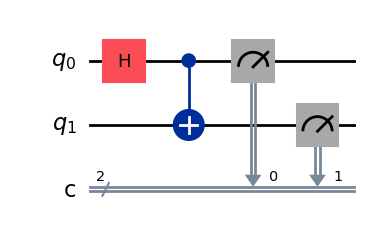

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# 1. Initialize a 2-qubit circuit (optionally add 2 classical bits for measurement)
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)

# 2. Add measurement so the simulator has data to collect
qc.measure([0, 1], [0, 1])

# 3. Draw the circuit locally using Matplotlib

qc.draw(output='mpl')



In [2]:
from qiskit.quantum_info import Pauli

ZZ = Pauli("ZZ")
ZI = Pauli("ZI")
IZ = Pauli("IZ")
XX = Pauli("XX")
XI = Pauli("XI")
IX = Pauli("IX")

observables = (ZZ, ZI, IZ, XX, XI, IX)
print("Observables Tuple:", observables)

Observables Tuple: (Pauli('ZZ'), Pauli('ZI'), Pauli('IZ'), Pauli('XX'), Pauli('XI'), Pauli('IX'))


In [3]:
from qiskit_aer.primitives import Estimator

# Match the number of circuits to the number of observables
circuits = [qc] * len(observables)

# Initialize the local Aer Estimator and execute
estimator = Estimator()
job = estimator.run(circuits, observables)
result = job.result()

# Extract expectation values
values = result.values
print("Expectation Values:", values)

Expectation Values: [ 1.          0.015625    0.015625    1.         -0.00585938 -0.00585938]


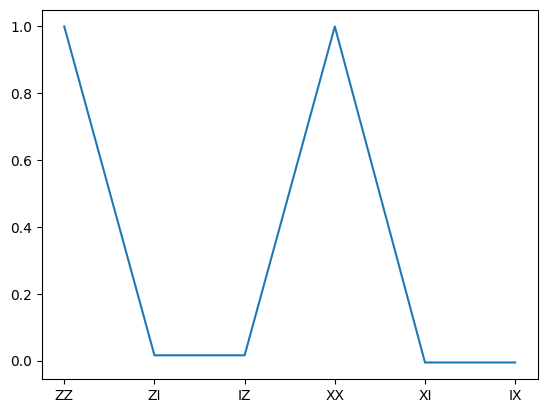

In [4]:
import matplotlib.pyplot as plt

data = ("ZZ", "ZI", "IZ", "XX", "XI", "IX")
values = job.result().values

plt.plot(data, values)
plt.show()

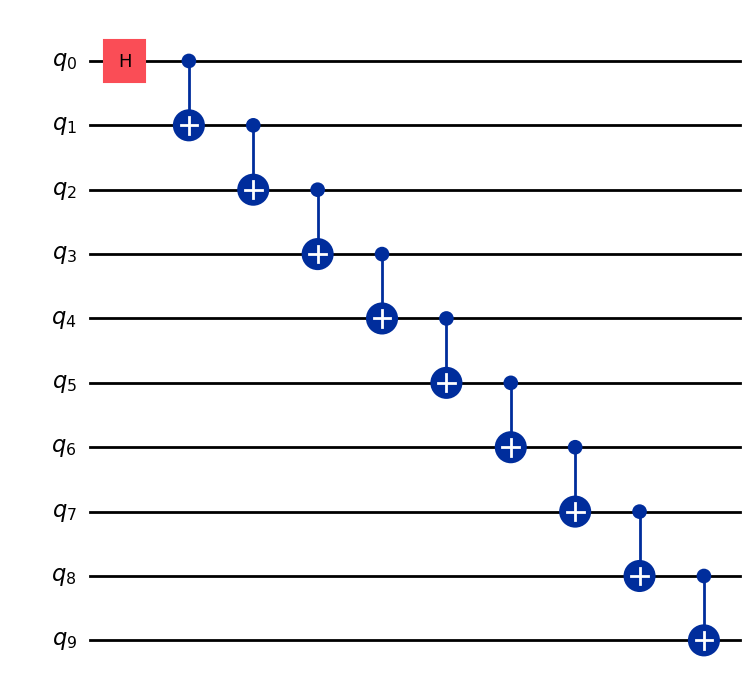

In [5]:

def get_qc_for_n_qubit_GHZ_state(n):
    qc = QuantumCircuit(n)
    qc.h(0)
    for i in range(n-1):
        qc.cx(i, i+1)
    return qc

n = 10
qc = get_qc_for_n_qubit_GHZ_state(n)
qc.draw(output='mpl')

In [6]:

from qiskit.quantum_info import SparsePauliOp

operator_strings = ['Z' + 'I' * i + 'Z' + 'I' * (n-2-i) for i in range(n-1)]
print(operator_strings)
print(len(operator_strings))

operators = [SparsePauliOp(operator_string) for operator_string in operator_strings]

['ZZIIIIIIII', 'ZIZIIIIIII', 'ZIIZIIIIII', 'ZIIIZIIIII', 'ZIIIIZIIII', 'ZIIIIIZIII', 'ZIIIIIIZII', 'ZIIIIIIIZI', 'ZIIIIIIIIZ']
9


In [ ]:

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager


backend = QiskitRuntimeService().least_busy(simulator=False, operational=True, min_num_qubits=100)
pass_manager = generate_preset_pass_manager(optimization_level=1, backend=backend)

qc_transpiled = pass_manager.run(qc)
operators_transpiled_list = [op.apply_layout(qc_transpiled.layout) for op in operators]

In [ ]:

from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import EstimatorOptions

options = EstimatorOptions()
options.resilience_level = 1
options.optimization_level = 0
options.dynamical_decoupling.enable = True
options.dynamical_decoupling.sequence_type = "XY4"

estimator = Estimator(backend, options=options)

job = estimator.run([(qc_transpiled, operators_transpiled_list)])
job_id = job.job_id()
print(job_id)

In [ ]:
job_id = 'cqq05tz267h0008fj6qg'
service = QiskitRuntimeService()
job = service.job(job_id)

In [ ]:

import matplotlib.pyplot as plt

data = list(range(1, len(operators)+1))
result = job.result()[0]
values = result.data.evs
values = [v / values[0] for v in values]

plt.scatter(data, values, marker='o', label='100-qubit GHZ state')
plt.xlabel('Distance between qubits $i$')
plt.ylabel(r'$\langle Z_0 Z_i \rangle / \langle Z_0 Z_1 \rangle$')
plt.legend()
plt.show()